## 문항 1. [맷플롯립] 2017년 지역별 미세먼지 세로 막대 그래프

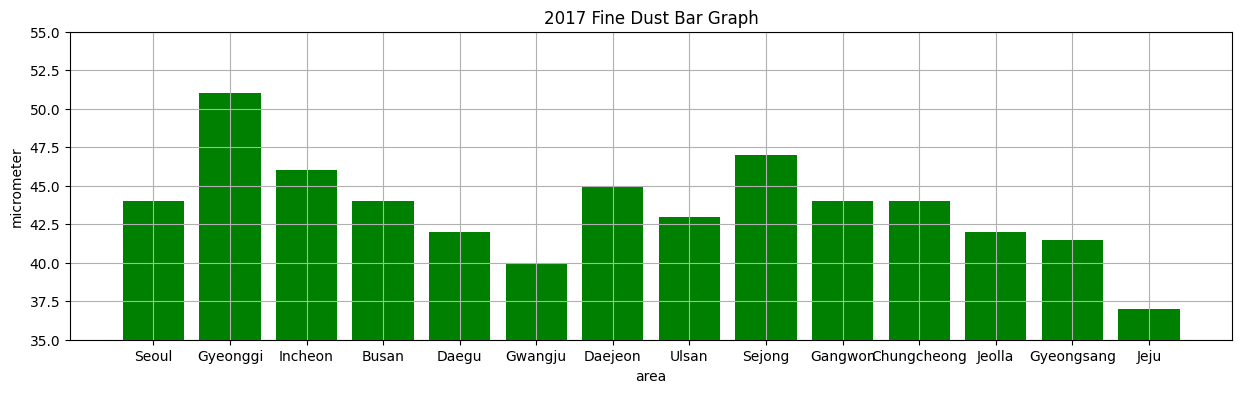

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel('fine_dust.xlsx', index_col='area')
data2017 =data[2017]
plt.figure(figsize=(15,4))
plt.bar(data2017.index, data2017, color='g')
plt.ylim(35,55)
plt.xlabel('area')
plt.ylabel('micrometer')
plt.title('2017 Fine Dust Bar Graph')
plt.grid()
plt.show()


## 문항 2. [맷플롯립] 키·몸무게 산점도 그래프

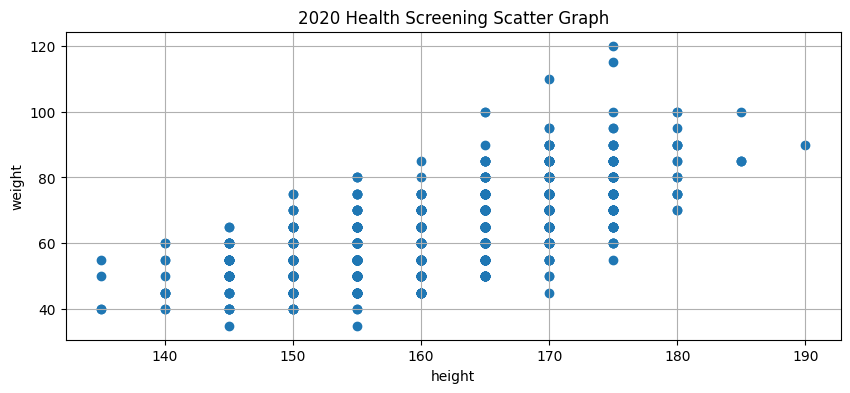

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel('health_screenings_2020_1000ea.xlsx')
heightdata = data['height']
weightdata = data['weight']

plt.figure(figsize=(10,4))
plt.scatter(heightdata, weightdata)
plt.xlabel('height')
plt.ylabel('weight')
plt.title("2020 Health Screening Scatter Graph")
plt.grid()
plt.show()

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_excel('health_screenings_2020_1000ea.xlsx')

# data6: 분석에 필요한 컬럼만 추출 후, 코드값을 문자열로 변환
data6 = data.loc[:, ['gender', 'height', 'weight', 'waist', 'drinking', 'smoking']]
data6['gender'] =data6['gender'].replace({1: 'Male', 2: 'Female'})
data6['drinking'] =data6['drinking'].replace({0: 'Non-drinking', 1: 'Drinking'})
data6['smoking'] =data6['smoking'].replace({1: 'Non-smoking', 2: 'Non-smoking', 3: 'Smoking'})

# male_data, femail_data: data6를 성별로 분리
male_data = data6.loc[data6.gender == 'Male', ['gender', 'weight', 'waist', 'drinking', 'smoking']]
female_data = data6.loc[data6.gender == 'Female', ['gender', 'weight', 'waist', 'drinking', 'smoking']]

## 문항 3. [시본] 성별 음주·흡연 상태 시본 막대 그래프 — 서브플롯

Text(0.5, 1.0, 'Smoking Type')

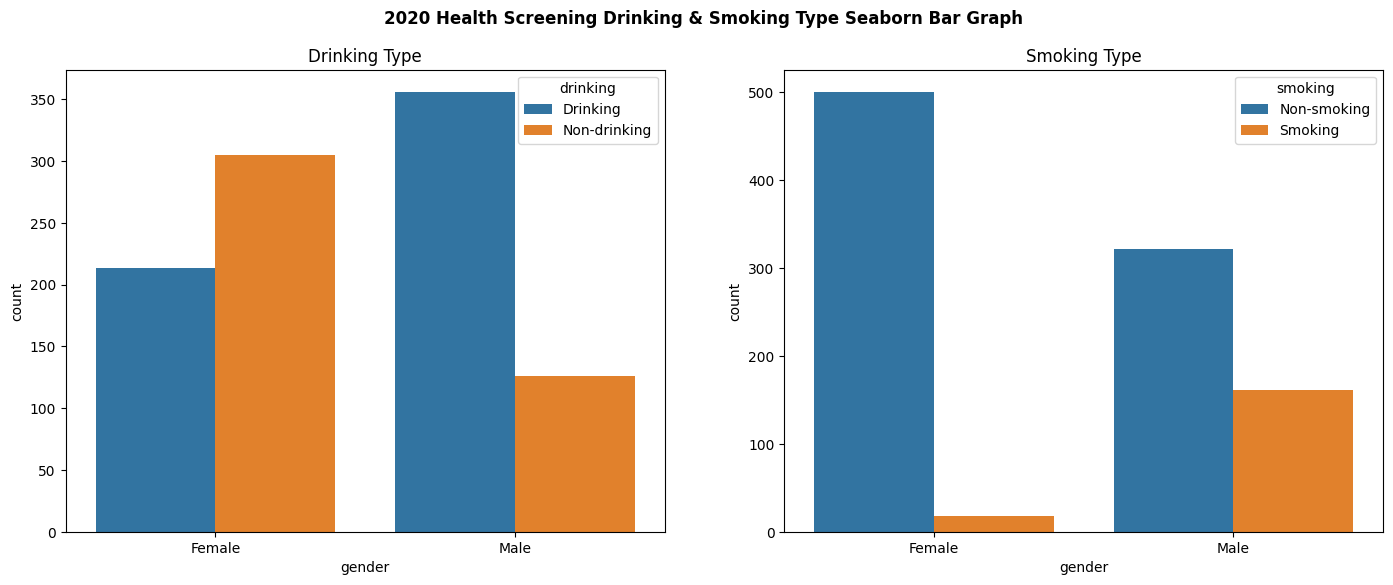

In [32]:

drinking = data6.groupby(['gender', 'drinking']).size().reset_index(name='count')
smoking = data6.groupby(['gender', 'smoking']).size().reset_index(name='count')

fig =plt.figure(figsize=(17,6))

area1 = fig.add_subplot(1, 2, 1)
area2 = fig.add_subplot(1, 2, 2)

ax1 = sns.barplot(data=drinking, x='gender', y='count', hue='drinking', ax=area1)
ax2 = sns.barplot(data=smoking, x='gender', y='count', hue='smoking', ax=area2)

fig.suptitle('2020 Health Screening Drinking & Smoking Type Seaborn Bar Graph', fontweight='bold')
area1.set_title('Drinking Type')
area2.set_title('Smoking Type')

## 문항 4. [시본] 남녀 허리둘레·몸무게 스트립 플롯 그래프

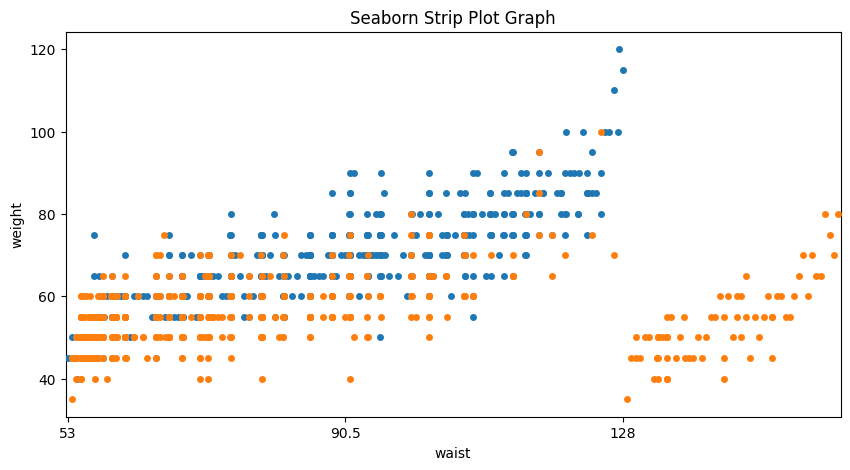

In [38]:
plt.figure(figsize=(10,5))
plt.title('Seaborn Strip Plot Graph')

sns.stripplot(data= male_data, x='waist', y='weight')
sns.stripplot(data= female_data, x='waist', y='weight')

plt.xticks(np.arange(0, 127, 63), labels=[53, 90.5, 128])
plt.show()


## 문항 5. [시본] 음주 여부별 허리둘레 분포 — 패싯 그리드 그래프

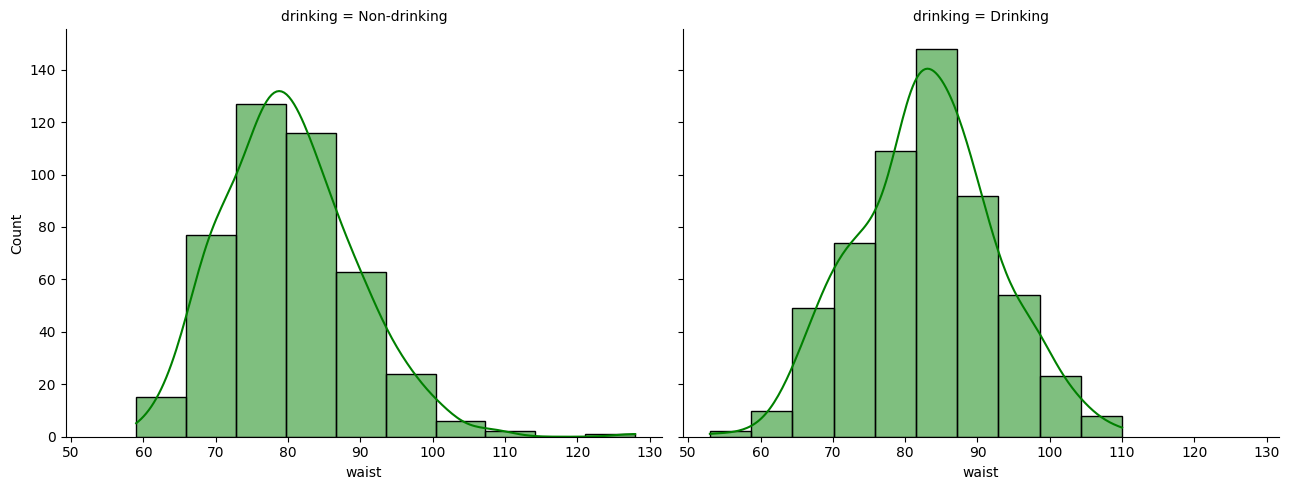

In [49]:
fg = sns.FacetGrid(data6, col='drinking', height=5, aspect=1.3)
fg.map(sns.histplot, 'waist', bins=10, color='g', kde=True)

plt.show()


## 문항 6. [시본] 남녀 몸무게 히스토그램 그래프

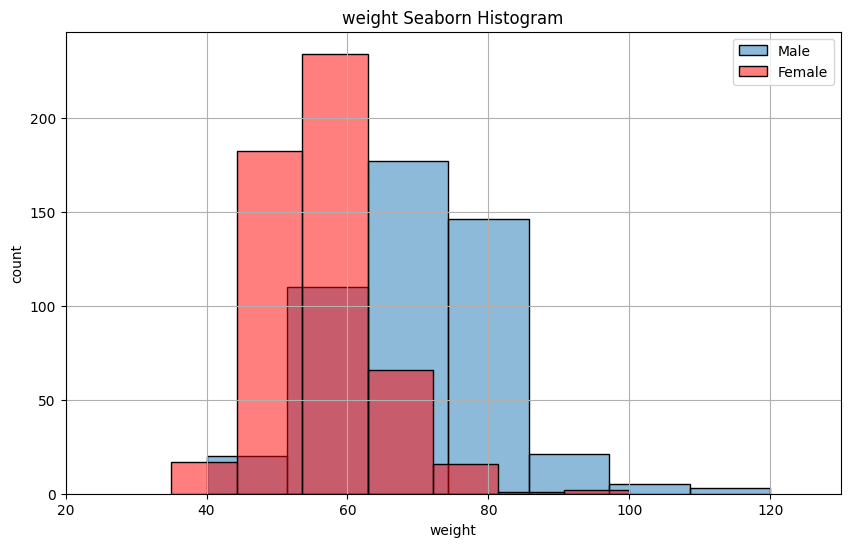

In [50]:
plt.figure(figsize=(10,6))
sns.histplot(male_data['weight'], bins=7, alpha=0.5, label='Male')
sns.histplot(female_data['weight'], bins=7, alpha=0.5, label='Female', color='r')

plt.xlim(20, 130)
plt.xlabel('weight')
plt.ylabel('count')
plt.title('weight Seaborn Histogram')
plt.legend()
plt.grid()
plt.show()


## 문항 7. [시본] 음주 여부·몸무게 상자수염 그래프

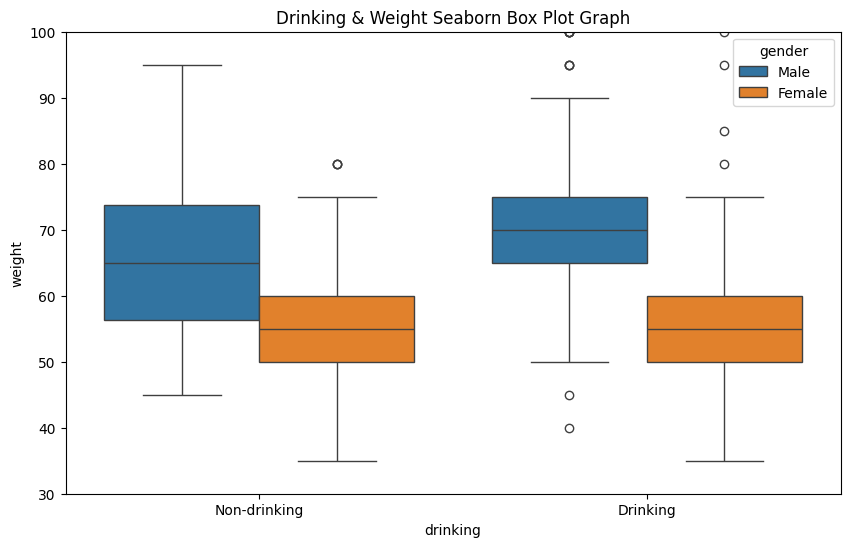

In [51]:
plt.figure(figsize=(10,6))
plt.title("Drinking & Weight Seaborn Box Plot Graph")

sns.boxplot(data=data6, x='drinking', y='weight', hue='gender')

plt.ylim(30, 100)
plt.show()

## 문항 8. [시본] 성별 음주 여부 카운트 플롯 그래프

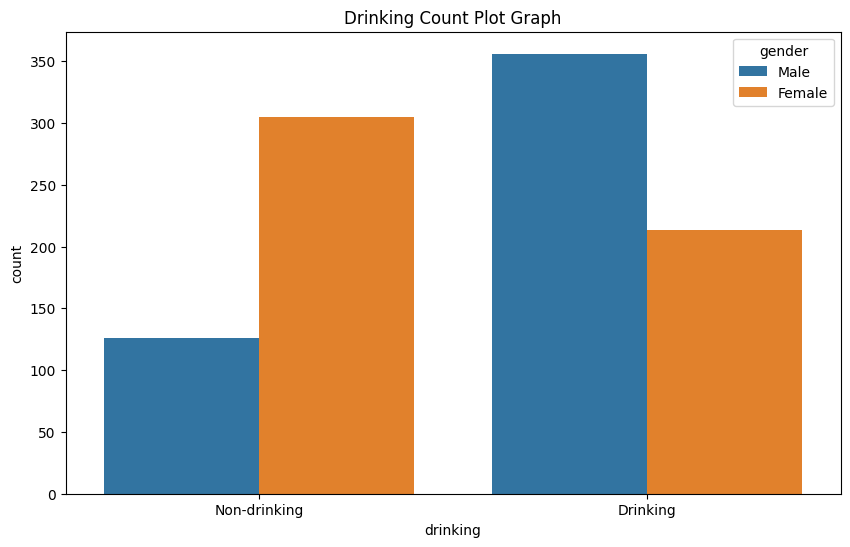

In [52]:
plt.figure(figsize=(10,6))
plt.title('Drinking Count Plot Graph')

sns.countplot(data=data6, x='drinking', hue='gender')

plt.show()

In [53]:
data6

,gender,height,weight,waist,drinking,smoking
0,Male,165,60,72.1,Non-drinking,Non-smoking
1,Female,150,65,81.0,Non-drinking,Non-smoking
2,Female,155,55,70.0,Non-drinking,Non-smoking
3,Male,160,70,90.8,Non-drinking,Non-smoking
4,Female,155,50,75.2,Non-drinking,Non-smoking
...,...,...,...,...,...,...
995,Male,165,70,92.0,Drinking,Smoking
996,Male,165,70,88.0,Non-drinking,Non-smoking
997,Female,155,55,80.2,Drinking,Non-smoking
998,Female,150,55,79.5,Non-drinking,Non-smoking


## 문항 9. [시본] 성별·음주 여부별 몸무게 바이올린 플롯 그래프

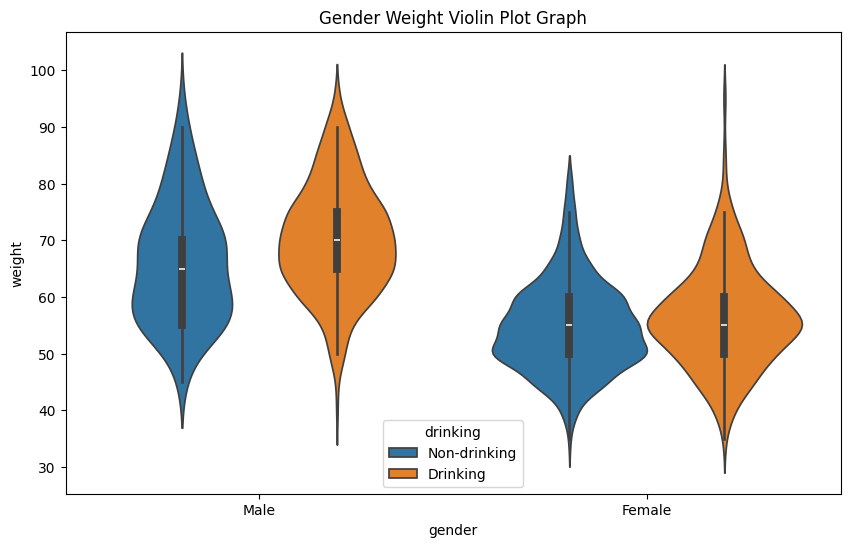

In [55]:
plt.figure(figsize=(10, 6))
plt.title("Gender Weight Violin Plot Graph")

sns.violinplot(data=data6[data6.weight<100], x='gender', y='weight', hue='drinking')

plt.show()

## 문항 10. [시본] 몸무게·허리둘레·성별 상관관계 히트맵 그래프

<Axes: title={'center': '3x3 Heat Map Graph'}>

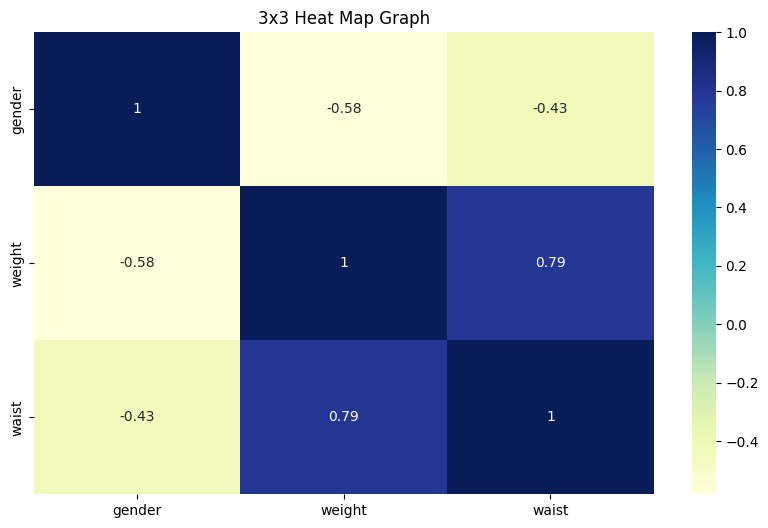

In [58]:
data3 = data.loc[:, ['gender', 'weight', 'waist']]

plt.figure(figsize=(10,6))
plt.title("3x3 Heat Map Graph")

correlation_data3 = data3.corr()
sns.heatmap(correlation_data3, annot=True, cmap='YlGnBu')